# Домашнее задание - линейная регрессия

### Работа с признаками (8 баллов)

Скачайте датасет из материалов к уроку или по ссылке https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv


Описание признаков:

* Agency — название страхового агентства
* Agency Type — тип страхового агентства
* Distribution Channel — канал продвижения страхового агентства
* Product Name — название страхового продукта
* Duration — длительность поездки (количество дней)
* Destination — направление поездки
* Net Sales — сумма продаж
* Commission (in value) — комиссия страхового агентства
* Gender — пол застрахованного
* Age — возраст застрахованного

Ответ:
* Claim — потребовалась ли страховая выплата: «да» — 1, «нет» — 0

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
link = "https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv"
data_frame = pd.read_csv(link)

In [3]:
df = data_frame.copy()
print(f'rows: {df.shape[0]}')
print(f'columns: {df.shape[1]}')
df.head(5)

rows: 63326
columns: 11


,Agency,Agency Type,Distribution Channel,Product Name,Claim,Duration,Destination,Net Sales,Commision (in value),Gender,Age
0,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,F,81
1,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,F,71
2,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,65,AUSTRALIA,-49.5,29.70,NaN,32
3,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,60,AUSTRALIA,-39.6,23.76,NaN,32
4,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,79,ITALY,-19.8,11.88,NaN,41


In [4]:
df.describe()

,Duration,Net Sales,Commision (in value),Age
count,63326.000000,63326.000000,63326.000000,63326.000000
mean,49.317074,40.702018,9.809992,39.969981
std,101.791566,48.845637,19.804388,14.017010
min,-2.000000,-389.000000,0.000000,0.000000
25%,9.000000,18.000000,0.000000,35.000000
50%,22.000000,26.530000,0.000000,36.000000
75%,53.000000,48.000000,11.550000,43.000000
max,4881.000000,810.000000,283.500000,118.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63326 entries, 0 to 63325
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Agency                63326 non-null  object 
 1   Agency Type           63326 non-null  object 
 2   Distribution Channel  63326 non-null  object 
 3   Product Name          63326 non-null  object 
 4   Claim                 63326 non-null  object 
 5   Duration              63326 non-null  int64  
 6   Destination           63326 non-null  object 
 7   Net Sales             63326 non-null  float64
 8   Commision (in value)  63326 non-null  float64
 9   Gender                18219 non-null  object 
 10  Age                   63326 non-null  int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 5.3+ MB


In [6]:
df.isna().sum()

,0
Agency,0
Agency Type,0
Distribution Channel,0
Product Name,0
Claim,0
Duration,0
Destination,0
Net Sales,0
Commision (in value),0
Gender,45107


In [7]:
print(f'isna_Gender: {round((df['Gender'].isna().sum() / df.shape[0]) * 100, 2)} %')

isna_Gender: 71.23 %


In [8]:
df['Gender'] = np.where(df['Gender'].isna(), 'no_said', df['Gender'])

# cat_features

In [9]:
cat_features = (df.columns[(df.dtypes == "object").values]).drop('Claim')

In [10]:
for cat_feature in cat_features:
    print(cat_feature, len(df[cat_feature].unique()))

Agency 16
Agency Type 2
Distribution Channel 2
Product Name 26
Destination 149
Gender 3


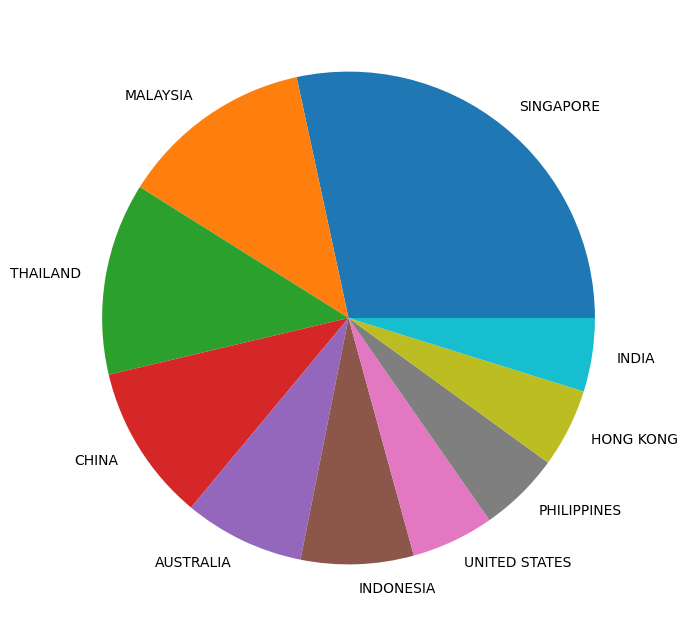

In [11]:
df['Destination'].value_counts().head(10).plot.pie(figsize=(8,8))
plt.ylabel("")
plt.show()

In [12]:
#df['Destination'].unique()
region_country = {
    "Asia": [
        "MALAYSIA","THAILAND","VIET NAM","SINGAPORE","JAPAN","INDONESIA",
        "INDIA","CHINA","PHILIPPINES","MYANMAR","HONG KONG",
        "KOREA, REPUBLIC OF","KOREA, DEMOCRATIC PEOPLE'S REPUBLIC OF",
        "TAIWAN, PROVINCE OF CHINA","SRI LANKA","CAMBODIA",
        "LAO PEOPLE'S DEMOCRATIC REPUBLIC","NEPAL","MACAO",
        "BANGLADESH","GEORGIA","TURKEY","MALDIVES","SAUDI ARABIA",
        "PAKISTAN","QATAR","MONGOLIA","ISRAEL","JORDAN","OMAN",
        "BAHRAIN","KAZAKHSTAN","AZERBAIJAN","UZBEKISTAN","KUWAIT",
        "ARMENIA","KYRGYZSTAN","LEBANON","TAJIKISTAN","TURKMENISTAN",
        "BHUTAN","IRAN, ISLAMIC REPUBLIC OF","TIBET"
    ],
    "Europe": [
        "ITALY","NORWAY","DENMARK","UNITED KINGDOM","FRANCE","POLAND",
        "SPAIN","CZECH REPUBLIC","GERMANY","AUSTRIA","NETHERLANDS",
        "CROATIA","FINLAND","RUSSIAN FEDERATION","GREECE","BELGIUM",
        "IRELAND","SWITZERLAND","ICELAND","PORTUGAL","ROMANIA",
        "ESTONIA","LUXEMBOURG","CYPRUS","SERBIA","HUNGARY",
        "SLOVENIA","BULGARIA","LITHUANIA","UKRAINE",
        "MOLDOVA, REPUBLIC OF","LATVIA","MALTA","ALBANIA",
        "MACEDONIA, THE FORMER YUGOSLAV REPUBLIC OF",
        "BELARUS","REPUBLIC OF MONTENEGRO","BOSNIA AND HERZEGOVINA",
        "FAROE ISLANDS"
    ],
    "Africa": [
        "NAMIBIA","SOUTH AFRICA","TANZANIA, UNITED REPUBLIC OF",
        "KENYA","ETHIOPIA","BENIN","UGANDA","GHANA","EGYPT",
        "SIERRA LEONE","GUINEA","ZIMBABWE","BOTSWANA","MALI",
        "ZAMBIA","NIGERIA","LIBYAN ARAB JAMAHIRIYA","ANGOLA",
        "GUINEA-BISSAU","CAMEROON","RWANDA","SENEGAL","MOROCCO"
    ],
    "North America": [
        "UNITED STATES","CANADA","COSTA RICA","MEXICO","PANAMA",
        "GUATEMALA","DOMINICAN REPUBLIC","BARBADOS",
        "TRINIDAD AND TOBAGO","JAMAICA","PUERTO RICO"
    ],
    "South America": [
        "CHILE","PERU","ARGENTINA","ECUADOR","BRAZIL",
        "URUGUAY","COLOMBIA","GUYANA","VENEZUELA","BOLIVIA"
    ],
    "Oceania": [
        "AUSTRALIA","NEW ZEALAND","FIJI","PAPUA NEW GUINEA",
        "VANUATU","SAMOA","SOLOMON ISLANDS"
    ],
    "Territories": [
        "GUAM","NEW CALEDONIA","VIRGIN ISLANDS, U.S.",
        "GUADELOUPE","BERMUDA","CAYMAN ISLANDS","REUNION",
        "SEYCHELLES","NORTHERN MARIANA ISLANDS",
        "TURKS AND CAICOS ISLANDS","FRENCH POLYNESIA"
    ]
}

In [13]:
country_region = dict()
for region, countries in region_country.items():
    for country in countries:
        country_region[country] = region

df['region'] = df['Destination'].map(country_region)
df['region'] = df['region'].fillna('other')

df.drop("Destination", axis=1, inplace=True)

In [14]:
cat_features = (df.columns[(df.dtypes == "object").values]).drop('Claim')

# распределение target

In [15]:
df['Claim'] = np.where(df['Claim'] == "Yes", 1, 0)

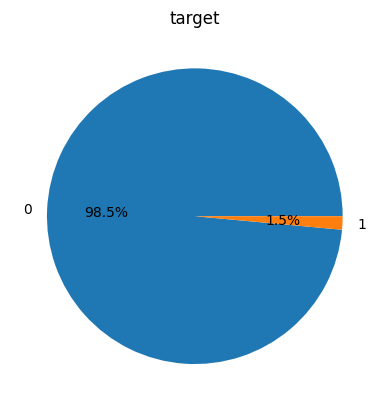

In [16]:
target_values = df['Claim'].value_counts()
plt.figure()
plt.pie(target_values, labels=target_values.index, autopct='%1.1f%%')
plt.title('target')
plt.show()

## сильный дизбаланс, модель с наибольшей вероятностью будет предсказывать класс 0,
### разобьем дату на train и test, поработаем с числовыми признаками, применим OHE и MinMax_SCALE

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X = df.drop('Claim', axis=1)
y = df['Claim']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [19]:
print(X_train.shape)

(50660, 10)


In [20]:
print(y_train.shape)

(50660,)


In [21]:
print(y.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Claim
0    0.985361
1    0.014639
Name: proportion, dtype: float64
Claim
0    0.985353
1    0.014647
Name: proportion, dtype: float64
Claim
0    0.985394
1    0.014606
Name: proportion, dtype: float64


# пропорции примерно одинаковые, отлично, гарантируем, что в выборках точно будет присутствовать класс единичек

## посмотрим на num_features

In [22]:
num_features = X_train.select_dtypes(include='number').columns.tolist()
num_features

['Duration', 'Net Sales', 'Commision (in value)', 'Age']

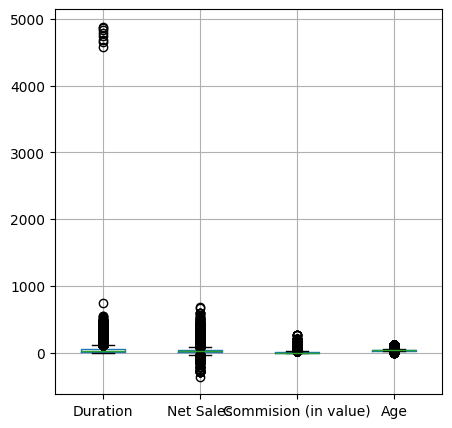

In [23]:
X_train[num_features].boxplot(figsize=(5, 5))
plt.show()

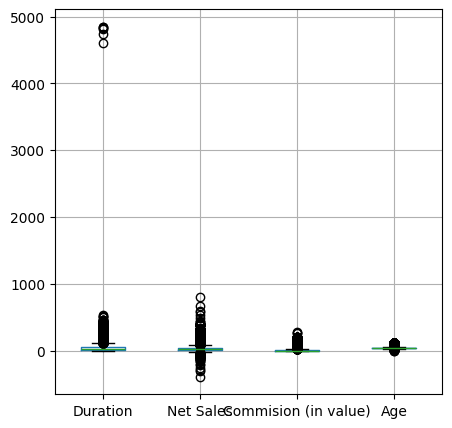

In [24]:
X_test[num_features].boxplot(figsize=(5,5))
plt.show()

# видим выбросы в Duration

In [25]:
X_train = X_train[X_train['Duration'] <= 1000]
X_test = X_test[X_test['Duration'] <= 1000]

y_train = y_train.loc[X_train.index]
y_test = y_test.loc[X_test.index]

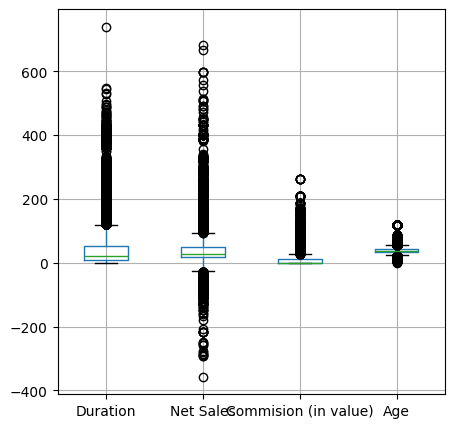

In [26]:
X_train[num_features].boxplot(figsize=(5, 5))
plt.show()

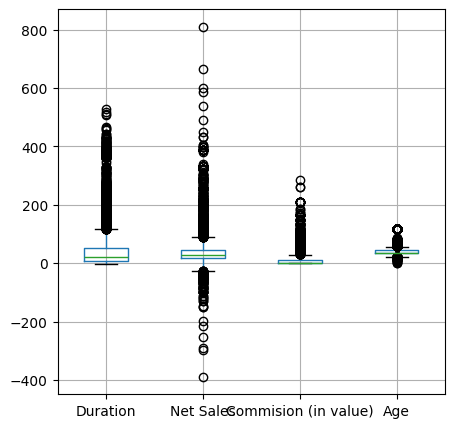

In [27]:
X_test[num_features].boxplot(figsize=(5,5))
plt.show()

In [28]:
X_train[X_train['Age'] >= 85]['Age'].value_counts()

,count
Age,
118,771
85,8
87,7
86,4
88,4


### очень подозрительно, что 118 летних людей по кол-ву 771, вероятно это ошибка, такого в природе не бывает, лучше уж заменить эти значения медианным

In [29]:
median_age = X_train['Age'].median()
X_train['Age'] = np.where(X_train['Age'] == 118, median_age, X_train['Age'])
X_test['Age'] = np.where(X_test['Age'] == 118, median_age, X_test['Age'])

In [30]:
X_train[num_features].min()

,0
Duration,-2.0
Net Sales,-357.5
Commision (in value),0.0
Age,0.0


### Duration не может быть меньше 0 (по логике), занчит это -> выбросы

In [31]:
X_train = X_train[X_train['Duration'] >= 0]
X_test = X_test[X_test['Duration'] >= 0]

y_train = y_train.loc[X_train.index]
y_test = y_test.loc[X_test.index]

In [32]:
print(X_train.shape)
print(y_train.shape)


(50648, 10)
(50648,)


In [33]:
print(X_test.shape)
print(y_test.shape)

(12659, 10)
(12659,)


### применю PowerTransformer к  Duration, Commision (in value) и Net Sales, чтобы побороться со скошенностью, после воспользуюсь самописным MinMax_scale, чтобы привести значения в пространство [0,1]

In [34]:
from sklearn.preprocessing import PowerTransformer

In [35]:
power_transformer = PowerTransformer(method='yeo-johnson')
power_transformer.fit(X_train[['Duration', 'Net Sales', 'Commision (in value)']])

col_pt = ['Duration', 'Net Sales', 'Commision (in value)']

X_train[col_pt] = power_transformer.transform(X_train[col_pt])
X_test[col_pt] = power_transformer.transform(X_test[col_pt])

#Обработайте пропущенные значения и примените написанные функции onehot_encode() и minmax_scale().

**Подсказка**: маску для категориальных признаков можно сделать фильтром cat_features_mask = (df.dtypes == "object").values

# MinMax_scale

In [36]:
class minmax_scale:
    def __init__(self):
        self.min_val = None
        self.max_val = None
        self.denominator = None

    def fit(self, data):
        data = np.array(data)
        self.min_val = data.min(axis=0)
        self.max_val = data.max(axis=0)
        self.denominator = self.max_val - self.min_val
        self.denominator = np.where(self.denominator == 0, 1, self.denominator)
        return self

    def transform(self, data):
        data = np.array(data)
        data = np.where(np.isinf(data), self.max_val, data)
        return ((data - self.min_val) / self.denominator)

    def fit_transform(self, data):
        self.fit(data)
        return self.transform(data)

In [37]:
mm_scale = minmax_scale()
mm_scale.fit(X_train[num_features])

X_train[num_features] = mm_scale.transform(X_train[num_features])
X_test[num_features] = mm_scale.transform(X_test[num_features])

# OneHotEncoder

In [38]:
class onehot_encoder:
    def __init__(self, drop_column=False):
        self.features_unique = dict()
        self.drop_column = drop_column

    def fit(self, arr, columns):
        for col in columns:
            self.features_unique[col] = np.unique(arr[col])

    def transform(self, arr, columns):
        final_matrix = []

        for col in columns:
            index_in_unique = np.searchsorted(self.features_unique[col], arr[col])
            ohe_matrix = np.zeros((len(arr[col]), len(self.features_unique[col])))

            for row in range(len(ohe_matrix)):
                ohe_matrix[row][index_in_unique[row]] = 1

            if self.drop_column:
                ohe_matrix = ohe_matrix[:,1:]

            final_matrix.append(ohe_matrix)

        return np.hstack(final_matrix)

    def fit_transform(self, arr, columns):
        self.fit(arr, columns)
        return self.transform(arr, columns)

In [39]:
onehot_encoder = onehot_encoder(drop_column=True)
onehot_encoder.fit(X_train, cat_features)

ohe_train = onehot_encoder.transform(X_train, cat_features)
ohe_test = onehot_encoder.transform(X_test, cat_features)

In [40]:
preprocessed_X_train = np.hstack([ohe_train, X_train[num_features].values])
preprocessed_X_test = np.hstack([ohe_test, X_test[num_features].values])

preprocessed_y_train = y_train.values
preprocessed_y_test = y_test.values

In [41]:
print(preprocessed_X_train.shape)
print(preprocessed_y_train.shape)

print(preprocessed_X_test.shape)
print(preprocessed_y_test.shape)

(50648, 54)
(50648,)
(12659, 54)
(12659,)


### думал на счет OVERSAMPLING, но дочитал задание до конца, у нас обычный лин рег, и смысла в oversampling и подборе вероятности порога вообще нет, таким образом просто сделаем DOWNSAMPLING

In [42]:
class_1 = preprocessed_y_train == 1
class_0 = preprocessed_y_train == 0

count_1 = sum(class_1)

random_0 = np.random.choice(np.where(class_0)[0], size=count_1, replace=False)

In [43]:
pool_1_0 = np.concatenate([np.where(class_1)[0], random_0])

In [44]:
final_X_train = preprocessed_X_train[pool_1_0]
final_y_train = preprocessed_y_train[pool_1_0]

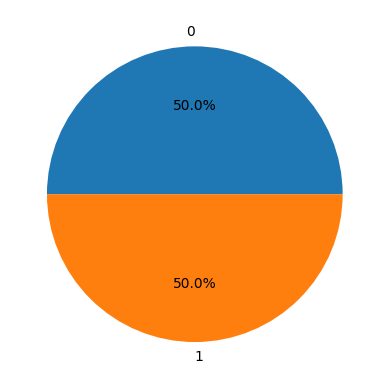

In [45]:
labels = ['0', '1']
plt.pie(np.bincount(final_y_train), labels=labels, autopct='%1.1f%%')
plt.show()

### Применение линейной регрессии (10 баллов)

Это задача классификации, но её можно решить с помощью линейной регрессии, если округлять предсказанный ответ до целого и выбирать ближайший по значению ответ из множества {0, 1}.

Вынесите признак 'Claim' в вектор ответов и разделите датасет на обучающую и тестовую выборку в соотношении 80 к 20. Зафиксируйте random_state.

**Подсказка:** быстро перевести Yes/No в 1/0 можно так - np.where(df['Claim'] == 'Yes', 1,0)

Найдите аналитическое решение для обучающей выборки: обычное и регуляризацией l2.

# обычное

In [71]:
X_train_bias = np.c_[np.ones(final_X_train.shape[0]), final_X_train]
X_test_bias = np.c_[np.ones(preprocessed_X_test.shape[0]), preprocessed_X_test]

In [72]:
theta_ols = np.linalg.pinv(X_train_bias) @ final_y_train

In [73]:
theta_ols

array([ 1.90831843e-01,  8.81972033e-02,  1.53095508e-01, -2.63634429e-01,
       -8.23362723e-02,  2.68934162e-01,  1.61972947e-01,  5.01142123e-01,
       -2.02892781e-03,  9.50247271e-03,  4.99816522e-01,  3.93948183e-01,
        1.24033910e-01,  9.81838383e-02, -2.99547242e-01,  2.56483937e-01,
       -2.80152162e-01, -5.50557090e-01,  2.02851619e-01, -2.78417434e-01,
       -1.22464943e-01, -2.16008192e-02, -7.57607160e-02, -1.17604639e-01,
       -1.62241448e-01, -1.85479101e-01,  1.22484070e-01, -2.78244929e-02,
       -9.59024224e-17, -7.70365398e-02,  7.86325872e-02,  1.37191658e-01,
       -2.77356269e-01,  1.61972947e-01,  9.60446127e-02,  3.38472216e-01,
        2.90362749e-01,  1.20720022e-01,  1.19292279e-01,  9.81838383e-02,
       -2.99547242e-01, -2.56158109e-01, -7.67097732e-02, -3.11672345e-01,
       -3.79965571e-02,  4.73037901e-02,  8.71541930e-02,  3.33596166e-02,
        3.66111349e-03,  0.00000000e+00, -7.11118453e-02,  1.98887116e-01,
        9.49097721e-01,  

# с L2

In [74]:
lambda_reg = 0.5
I = np.eye(X_train_bias.shape[1])

I[0, 0] = 0

In [75]:
theta_l2 = np.linalg.inv((X_train_bias.T @ X_train_bias) + lambda_reg * I) @ (X_train_bias.T @ final_y_train)

In [76]:
theta_l2

array([ 0.26186778,  0.00129347,  0.19655426, -0.22065637, -0.08404366,
        0.16966001,  0.0165256 ,  0.20262251, -0.06004756, -0.05339876,
        0.22473178,  0.29043681, -0.00468579,  0.03265933, -0.31789593,
        0.19385675, -0.11237495, -0.48108596,  0.20566855, -0.11413496,
       -0.07731504,  0.00138817, -0.06737423, -0.08446659, -0.15378542,
       -0.09454269,  0.11103757, -0.02941701,  0.        , -0.13504002,
        0.07159781,  0.11502283, -0.11126035,  0.0165256 ,  0.08984575,
        0.28883449,  0.2299084 ,  0.07732017,  0.07883391,  0.03265933,
       -0.31789593, -0.15978131, -0.07417789, -0.15550468, -0.04556743,
        0.04277946,  0.08692911,  0.03389914,  0.00435111,  0.        ,
       -0.0709722 ,  0.20524308,  0.66931888,  0.41080873, -0.06904107])

In [77]:
y_pred_ols_analytical = X_test_bias @ theta_ols
y_pred_l2_analytical = X_test_bias @ theta_l2

In [78]:
mse_ols_analytical = mean_squared_error(preprocessed_y_test, y_pred_ols_analytical)
mse_l2_analytical = mean_squared_error(preprocessed_y_test, y_pred_l2_analytical)

In [79]:
print(f'MSE Analytical OLS: {round(mse_ols_analytical, 4)}')
print(f'MSE Analytical L2:  {round(mse_l2_analytical, 4)}')

MSE Analytical OLS: 0.1648
MSE Analytical L2:  0.1651


Постройте модель LinearRegression, примените к тестовой выборке и посчитайте MSE (можно использовать библиотеку sklearn)

In [80]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

In [81]:
model_lr = LinearRegression()

model_lr.fit(final_X_train, final_y_train)

y_pred_lr = model_lr.predict(preprocessed_X_test)
mse_lr = mean_squared_error(preprocessed_y_test, y_pred_lr)

In [82]:
model_ridge = Ridge(alpha=1.0)

model_ridge.fit(final_X_train, final_y_train)

y_pred_ridge = model_ridge.predict(preprocessed_X_test)
mse_ridge = mean_squared_error(preprocessed_y_test, y_pred_ridge)

In [83]:
print(f'MSE (LinearRegression): {round(mse_lr, 4)}')
print(f'MSE (Ridge L2):         {round(mse_ridge, 4)}')

MSE (LinearRegression): 0.1648
MSE (Ridge L2):         0.1654


### Вывод (1 балла)

Напишите краткий вывод по заданию (достаточно пары предложений). Расскажите, какие способы предобработки данных вы выбрали и почему. Насколько хороша ваша модель?



---


# *Я подготовил данные, удалив аномалии, сгруппировав страны и сбалансировав количество страховых случаев. Числа я нормализовал и привел к одному масштабу для стабильности расчетов.*


# *Модель получилась точной: мои аналитические формулы совпали с библиотекой sklearn, а ошибка MSE 0.16 говорит о том, что линейная зависимость найдена верно. Регуляризация (L2) помогла избежать переобучения на лишних признаках, сделав прогноз более надежным.*


---

